In [30]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, cartopy, geopandas as gpd, numpy as np

mapproj = cartopy.crs.AlbersEqualArea(central_longitude = 1.0, central_latitude = 47.0)
sf = gpd.read_file("../sf_fennoscandia").set_crs("epsg:4326").to_crs(mapproj)

Xn,Xx,Yn,Yx = [0,31.9,54,73]

In [19]:
# project coordinates for plotting
def project_latlon(da, to_crs):
        
    if "lon" in da.coords: da = da.rename(lon = "longitude", lat = "latitude")
    
    # convert dataArray to dataframe
    df = da.to_dataframe().reset_index()
    
    # convert to geoDataFrame, reproject points to Statistics Canada Lambert 
    gdf = gpd.GeoDataFrame(df[df.columns[-1]], geometry = gpd.points_from_xy(df.longitude, df.latitude))
    gdf = gdf.set_crs(epsg = 4326).to_crs(to_crs)
    
    x = np.reshape(np.array(gdf.geometry.x), da.shape)
    y = np.reshape(np.array(gdf.geometry.y), da.shape)
    
    return x,y

# Map of gridded trend

In [23]:
fnm = "../data/gridded-trend_tx14x_era5.nc"

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# load gridded model results
res = xr.open_dataset(fnm)

# get projected coordinates for plotting
x,y = project_latlon(res.dI_abs, to_crs = mapproj)

In [ ]:

fig, axs = plt.subplots(ncols = 2, subplot_kw = {"projection" : mapproj, "extent" : (Xn,Xx,Yn,Yx)}, figsize = (13,7.5), dpi = 100)
plt.subplots_adjust(hspace = 0.01)

for i in range(2):
    ax = axs[i]
    ds = [tx14x, tn14x][i]
    
    da = ds.hw_2025
    date_range = ds.date_range

    px = sites.loc[sites.rtype == ["max", "min"][i]]
    
    vrange = [{"vmin" : 15, "vmax" : 30}, {"vmin" : 9, "vmax" : 20}][i]
    
    cbar = ax.pcolormesh(x,y, da, cmap = "YlOrRd", **vrange)
    px.plot(ax = ax, marker = "x", color = "k")
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.4, ls = "--")
    ax.gridlines(color = "k", alpha = 0.1, draw_labels = ["bottom", "left"])
    plt.colorbar(cbar, ax = ax, location = "bottom", shrink = 0.85, pad = 0.1, fraction = 0.1, label = "Average "+["max", "min"][i]+"imum temperature (°C)", extend = "max")
    ax.set_title(titles[i]+" temperature\n("+date_range+")", fontweight = "bold")
    sf.to_crs(mapproj).boundary.plot(ax = ax, color = "darkblue", lw = 2)

plt.savefig("fig/event-map.png")

In [ ]:
nr = 1; nc = 1

fig, ax = plt.subplots(ncols = nc, nrows = nr, figsize = (nc * 5, nr * 3.75), dpi = 100, subplot_kw = {"projection" : mapproj, "extent" : (Xn,Xx,Yn,Yx)})

cbar_kwargs = {"location" : "bottom", "pad" : 0.02}

cbar = ax.pcolormesh(x,y, res.dI_abs, cmap = "YlOrRd", vmin = 0, vmax = 5)

# res.dI_abs.plot(ax = ax, cmap = "YlOrRd", , cbar_kwargs = cbar_kwargs | {"label" : "Change in temperature (degC)"})
# ax.set_title("Change in intensity")

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
ax.gridlines(color = "k", alpha = 0.1)
sf.boundary.plot(ax = ax, color = "darkblue")

plt.colorbar(cbar, ax = ax, **cbar_kwargs)

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


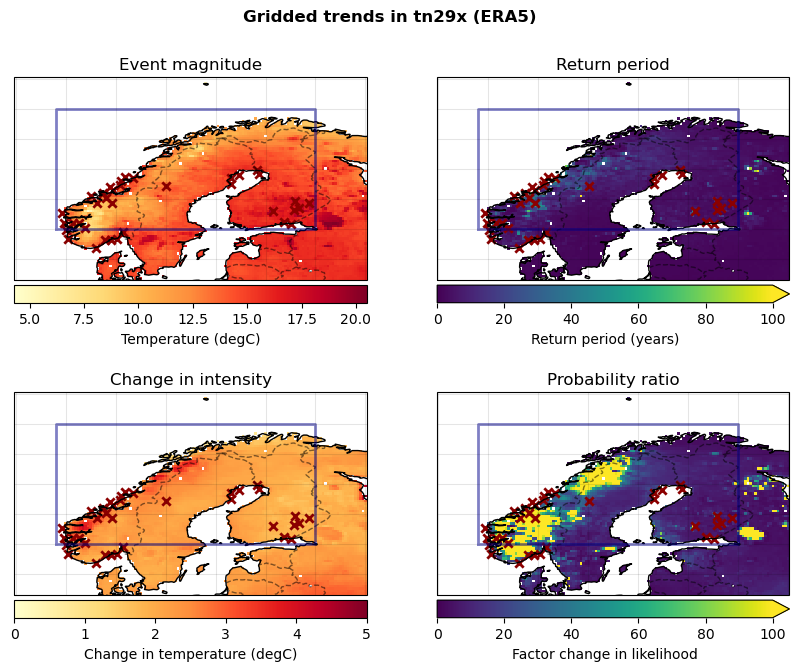

In [ ]:
nr = 2; nc = 2
fig, axs = plt.subplots(ncols = nc, nrows = nr, figsize = (nc * 5, nr * 3.75), dpi = 100, subplot_kw = {"projection" : mapproj})
plt.subplots_adjust(hspace = 0.2)
axs = axs.flatten()

cbar_kwargs = {"location" : "bottom", "pad" : 0.02}

res.event_magnitude.plot(ax = axs[0], cmap = "YlOrRd", cbar_kwargs = cbar_kwargs | {"label" : "Temperature (degC)"})
axs[0].set_title("Event magnitude")

res.return_period.plot(ax = axs[1], cmap = "viridis", vmin = 0, vmax = 100, cbar_kwargs = cbar_kwargs | {"label" : "Return period (years)"})
axs[1].set_title("Return period")

res.dI_abs.plot(ax = axs[2], cmap = "YlOrRd", vmin = 0, vmax = 5, cbar_kwargs = cbar_kwargs | {"label" : "Change in temperature (degC)"})
axs[2].set_title("Change in intensity")

res.PR.plot(ax = axs[3], cmap = "viridis", vmin = 0, vmax = 100, cbar_kwargs = cbar_kwargs | {"label" : "Factor change in likelihood"})
axs[3].set_title("Probability ratio")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
    ax.plot([xn,xn,xx,xx,xn], [yn,yx,yx,yn,yn], color = "darkblue", lw = 2, alpha = 0.5)
    ax.gridlines(color = "k", alpha = 0.1)

    ax.scatter(px.lon, px.lat, marker = "x", color = "darkred", lw = 2)
    
plt.suptitle("Gridded trends in "+fnm.split("_")[1]+" ("+fnm.split("_")[-1][:-3].upper()+")", fontweight = "bold", y = 0.95)
    
plt.savefig("fig/"+fnm[:-3]+".png")